In [1]:
import pandas as pd
import numpy as np

cancers = ['ccRCC', 'Melanoma', 'NSCLC']
seeds = [42,0,1,2,3]

# datasets = [f'avatarsk5_{seed}', f'avatarsk10_{seed}',f'ctgan_{seed}',f'gaussiancopula_{seed}',f'synthpop_{seed}',f'tvae_{seed}']
names = ['Avatars K5', 'Avatars K10', 'CTGAN', 'Gaussian Copula', 'Synthpop', 'TVAE']

Univariate_Score_Dict = {}
for cancer in cancers:
    score_dict = {}
    for i, name in enumerate(names):
        methods_score = []
        for seed in seeds:
            datasets = [f'avatarsk5_{seed}', f'avatarsk10_{seed}',f'ctgan_{seed}',f'gaussiancopula_{seed}',f'synthpop_{seed}',f'tvae_{seed}']
            uni_clinical_df = pd.read_csv(f'../{cancer}/BroadUtility/UniClinicalSimi/UniClinicalSimi_{seed}/Detail_score_{datasets[i]}.csv')
            score_clinical_1_seed = np.mean(uni_clinical_df["Score"].fillna(0).tolist())
            
            uni_omic_df = pd.read_csv(f'../{cancer}/BroadUtility/UniTranscriptomicsSimi/UniTranscriptomicsSimi_{seed}/Detail_score_{datasets[i]}.csv')
            score_omic_1_seed = np.mean(uni_omic_df["Score"].fillna(0).tolist())
             
            overal_score_seed = 0.5*(score_omic_1_seed+score_clinical_1_seed)
            
            methods_score.append(overal_score_seed)
            
        score_dict[name] = methods_score
    Univariate_Score_Dict[cancer] = score_dict

In [2]:
for cancer, synthetic_dict in Univariate_Score_Dict.items():
    print(f"\n--- CANCER: {cancer} ---")

    header = f"{'Synthetic Method':<25} | {'Mean ± STD':^25}"
    print(header)
    print("-" * len(header))
    
    for syntheticdata, scores in synthetic_dict.items():
        avg = np.mean(scores)
        std = np.std(scores)
        
        score_display = f"{avg:.3f} ± {std:.3f}"
        
        print(f"{syntheticdata:<25} | {score_display:^25}")


--- CANCER: ccRCC ---
Synthetic Method          |        Mean ± STD        
-----------------------------------------------------
Avatars K5                |       0.890 ± 0.001      
Avatars K10               |       0.869 ± 0.002      
CTGAN                     |       0.818 ± 0.010      
Gaussian Copula           |       0.889 ± 0.003      
Synthpop                  |       0.952 ± 0.001      
TVAE                      |       0.627 ± 0.027      

--- CANCER: Melanoma ---
Synthetic Method          |        Mean ± STD        
-----------------------------------------------------
Avatars K5                |       0.857 ± 0.002      
Avatars K10               |       0.843 ± 0.002      
CTGAN                     |       0.767 ± 0.016      
Gaussian Copula           |       0.893 ± 0.001      
Synthpop                  |       0.924 ± 0.005      
TVAE                      |       0.802 ± 0.017      

--- CANCER: NSCLC ---
Synthetic Method          |        Mean ± STD        
----------

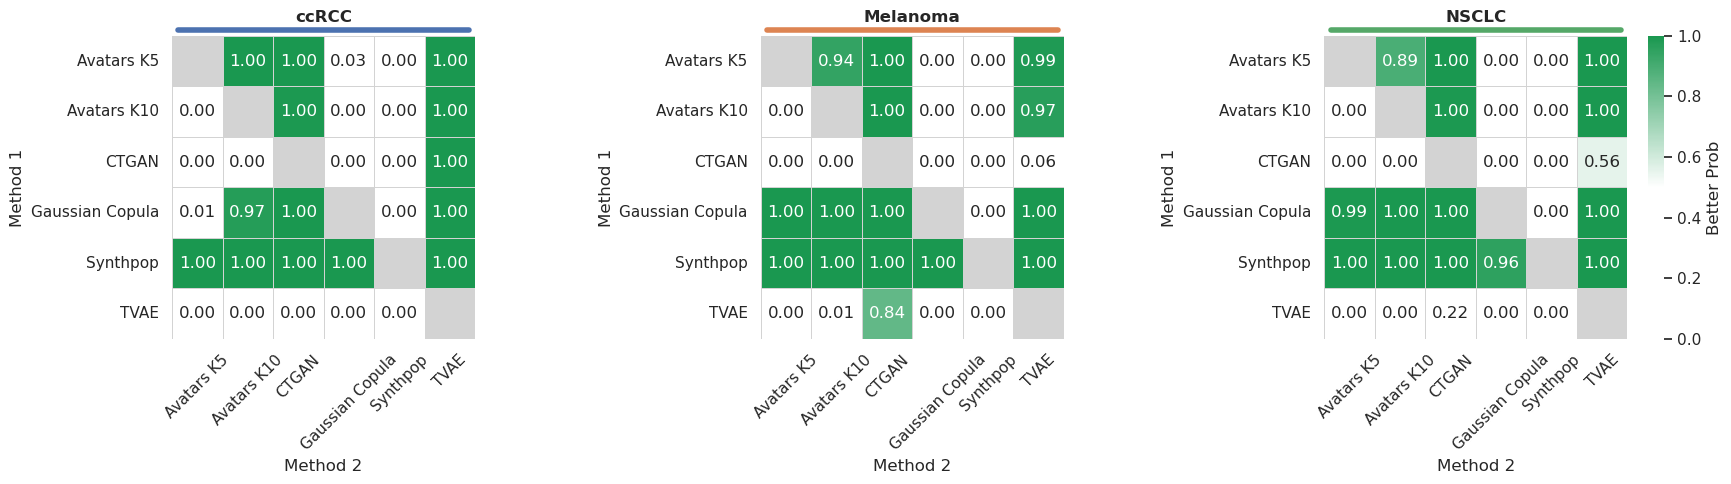

In [13]:
from SynOmics.metrics.fidelity.BayesianComparison import  BayesianComparison

bc = BayesianComparison(rope=0.01)
methods_order = ["Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", "TVAE"]
fig_c, axes, mats_by_cancer, comp_by_cancer = bc.plot_pbetter_heatmap_grid(
    cancer_to_method_scores=Univariate_Score_Dict,
    cancers_order=["ccRCC", "Melanoma", "NSCLC"],
    methods_order=methods_order,
    value_col="Better Prob", 
    figsize=(18, 5),
    annot=True,
    fmt=".2f",
)

fig_c.savefig("bayesian_comp_fig2c_uni.pdf", bbox_inches="tight", facecolor="white")
for cancer in cancers:
    bayesian_comp_df = comp_by_cancer[cancer]
    bayesian_comp_df.to_csv(f'UnivariateBayesian_estimation_{cancer}.csv')